In [1]:
from frameworks.LightenDiffusion.models.LightenDiffusion import Stage1, Stage2, LightenDiffusionPipeline
from frameworks.LightenDiffusion.models.unet import DiffusionUNet
from dataset_registery.registery import DatasetManager
from frameworks.LightenDiffusion.models.decom import ImageEncoder, ImageDecoder, RetinexDecomposition
from frameworks.LightenDiffusion.training.stage2 import Stage2Trainer
from eda.helpers.data_helpers import split_dataloader
from eda.helpers.training_helpers import get_optimizer, get_scheduler
from frameworks.LightenDiffusion.losses import stage2_loss_wrapper
import os
import torch
%load_ext autoreload
%autoreload 2

In [2]:
data_name = "SICE_paired"
dataset_id = "okhater/SICE"
source = "huggingface"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device used : {device}")

Device used : cuda


In [3]:
registry = DatasetManager()
registry.initialize_dataset(
    name=data_name,
    dataset_id=dataset_id,
    splits=["train", "test"],
    dataset_type="paired",
    hf_cache_dir=f"../../datasets/{data_name}",
)

train_loader = registry.get_dataloader(data_name, "train", batch_size=8, shuffle=True)
test_loader = registry.get_dataloader(data_name, "test", batch_size=8, shuffle=True)
train_loader, val_loader = split_dataloader(train_loader, split_ratio=0.2)

loaders = {
    "train": train_loader, 
    "val": val_loader, 
    "test": test_loader
    }
for name, loader in loaders.items():
    total_samples = len(loader.dataset)
    print(f"Loader: {name}, Total samples: {total_samples}")
    for low_imgs, label in loader:
        print(f"Batch contains {len(low_imgs)} low image samples.")
        print("Low images batch shape:", low_imgs.shape)
        print("Label batch shape:", label.shape)
        break
    print("==="*20)

Resolving data files:   0%|          | 0/1280 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/223 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1280 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/223 [00:00<?, ?it/s]

Loader: train, Total samples: 207
Batch contains 8 low image samples.
Low images batch shape: torch.Size([8, 2, 3, 256, 256])
Label batch shape: torch.Size([8, 3, 256, 256])
Loader: val, Total samples: 51
Batch contains 8 low image samples.
Low images batch shape: torch.Size([8, 2, 3, 256, 256])
Label batch shape: torch.Size([8, 3, 256, 256])
Loader: test, Total samples: 46
Batch contains 8 low image samples.
Low images batch shape: torch.Size([8, 2, 3, 256, 256])
Label batch shape: torch.Size([8, 3, 256, 256])


In [4]:
directory = "/home/grads/o/omarkhater/projects/lle-generative-priors/frameworks/LightenDiffusion/trained_models/stage1/"
file_path = os.path.join(directory, "stage1_beta2.pth")
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found: {file_path}")
stage1_model_weights = torch.load(file_path, map_location=device)
latent_space_dim = 64
stage1_model = Stage1(
    encoder=ImageEncoder(latent_space_dim),
    decoder=ImageDecoder(latent_space_dim),
    decomposer=RetinexDecomposition(channels=latent_space_dim),
)
stage1_model.load_state_dict(stage1_model_weights)


<All keys matched successfully>

In [5]:
diffusion_net = DiffusionUNet(
    in_channels=latent_space_dim*2,
    out_channels=latent_space_dim,
    ch=64,
    ch_mult=(1, 2, 3, 4),
    num_res_blocks=2,
    dropout=0.0,
    conditional=True,
    resamp_with_conv=True,
)
stage2_model = Stage2(
    diffusion_unet=diffusion_net,
)

In [6]:
model = LightenDiffusionPipeline(
    stage1=stage1_model,
    stage2=stage2_model
)

model.to(device)

LightenDiffusionPipeline(
  (stage1): Stage1(
    (encoder): ImageEncoder(
      (pyramid): FeaturePyramid(
        (initial_convs): Sequential(
          (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
          (1): Conv2d(64, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
        )
        (levels): ModuleList(
          (0): Sequential(
            (0): Res_block(
              (model): Sequential(
                (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
                (1): LeakyReLU(negative_slope=0.01)
                (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
              )
              (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
            )
            (1): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          )
          (1): Sequential(
            (0): Res_block(
              (model): Sequential(
                (0): Conv2d(64, 128, kernel_size=(3

In [7]:
stage2_optimizer = get_optimizer(
    stage2_model,
    lr = 1e-4,
    weight_decay = 1e-4
    )
stage2_scheduler = get_scheduler(stage2_optimizer, gamma=.8)

Training Epochs:   0%|          | 0/5 [00:00<?, ?epoch/s]

Training Batches:   0%|          | 0/26 [00:00<?, ?batch/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

...




Evaluating Stage2 (Average-First): 100%|██████████| 7/7 [00:35<00:00,  5.05s/it]


{'psnr': np.float64(10.878154250279593),
 'ssim': np.float64(0.3447203024775678),
 'lpips': 0.7994659028801263,
 'niqe': 11.541352653058405,
 'pi': 6.1704092779692665}

Visualizing Stage2 results


Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

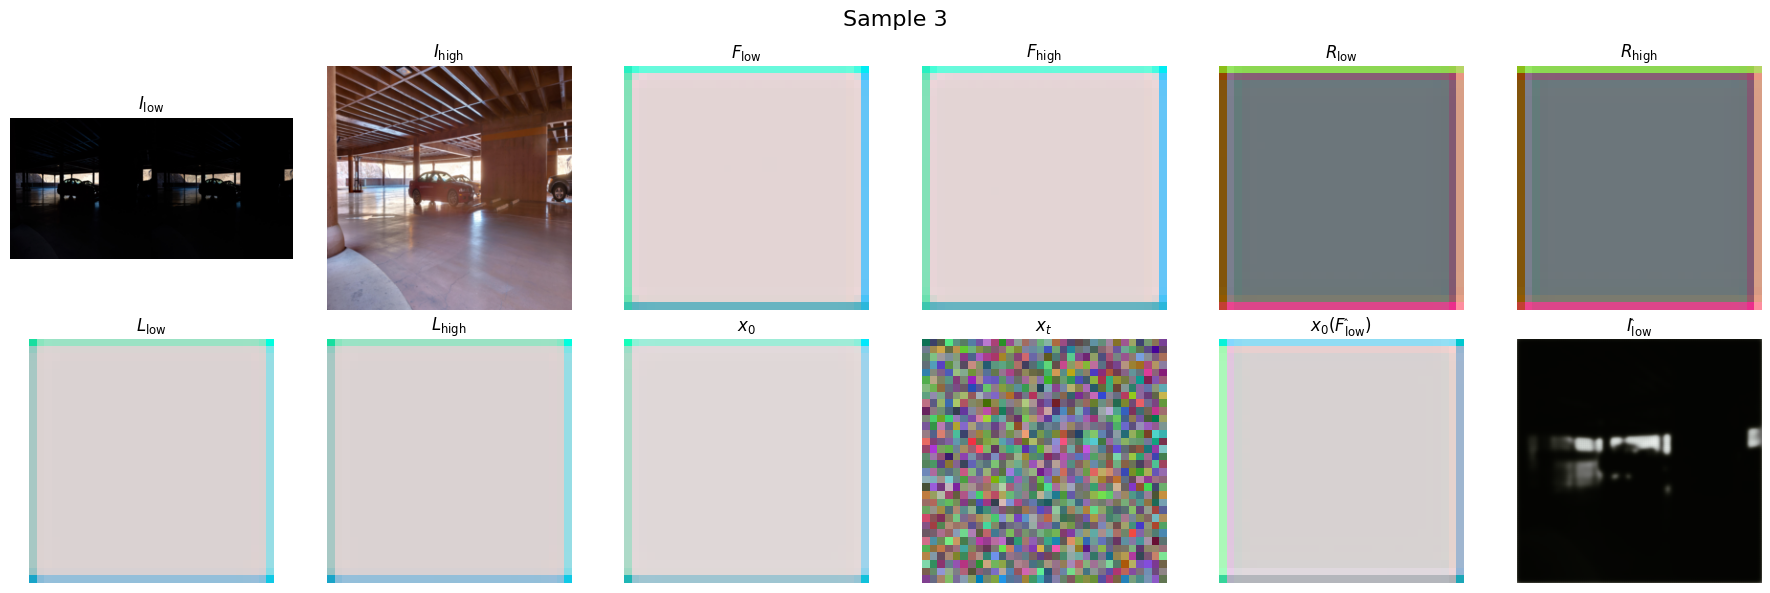

Training Batches:   0%|          | 0/26 [00:00<?, ?batch/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

...




Evaluating Stage2 (Average-First): 100%|██████████| 7/7 [00:35<00:00,  5.09s/it]


{'psnr': np.float64(11.008559137141097),
 'ssim': np.float64(0.3469444828121498),
 'lpips': 0.8002878614500457,
 'niqe': 13.284406418242874,
 'pi': 7.042347139846458}

Visualizing Stage2 results


Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

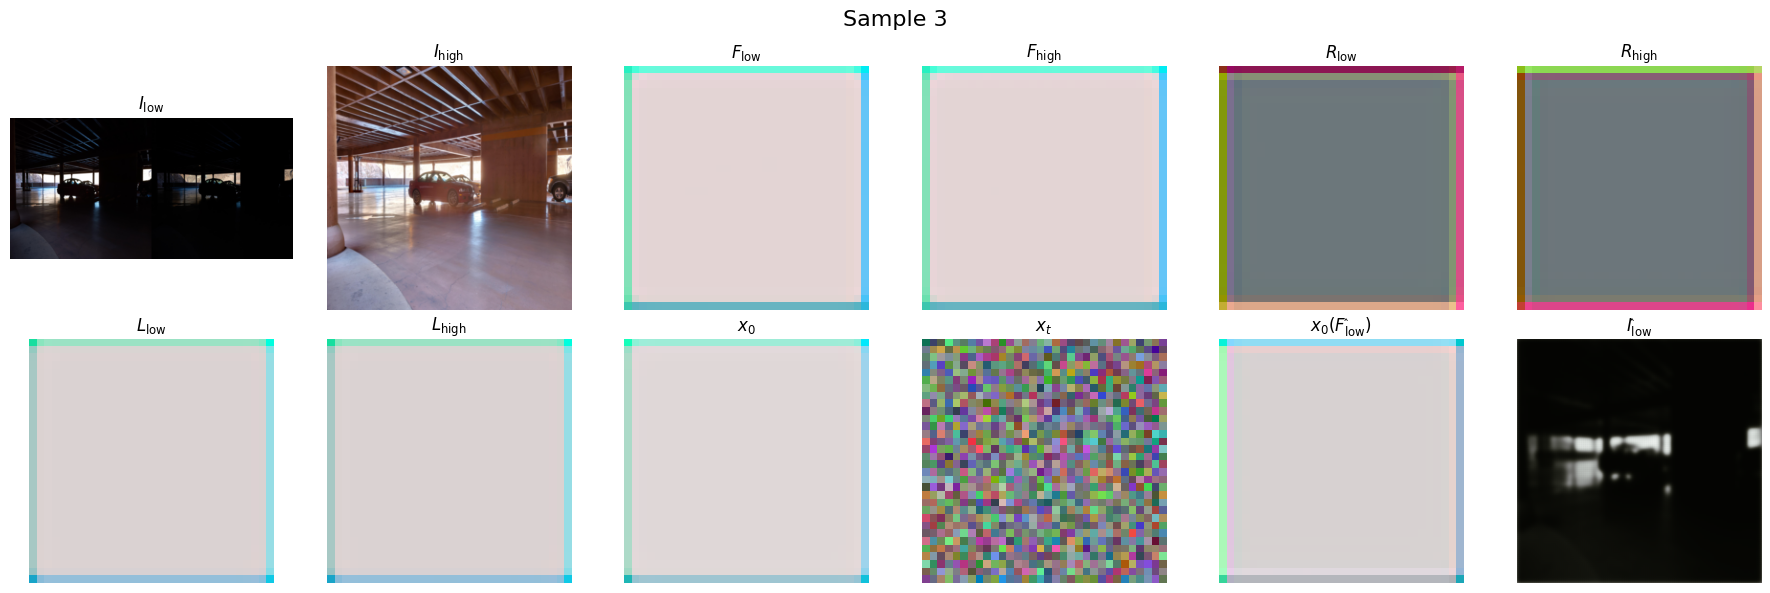

Training Batches:   0%|          | 0/26 [00:00<?, ?batch/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

...




Evaluating Stage2 (Average-First): 100%|██████████| 7/7 [00:33<00:00,  4.84s/it]


{'psnr': np.float64(11.05478954355371),
 'ssim': np.float64(0.3423826946933643),
 'lpips': 0.8084320390925688,
 'niqe': 13.496852014680627,
 'pi': 7.152642026886598}

Visualizing Stage2 results


Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

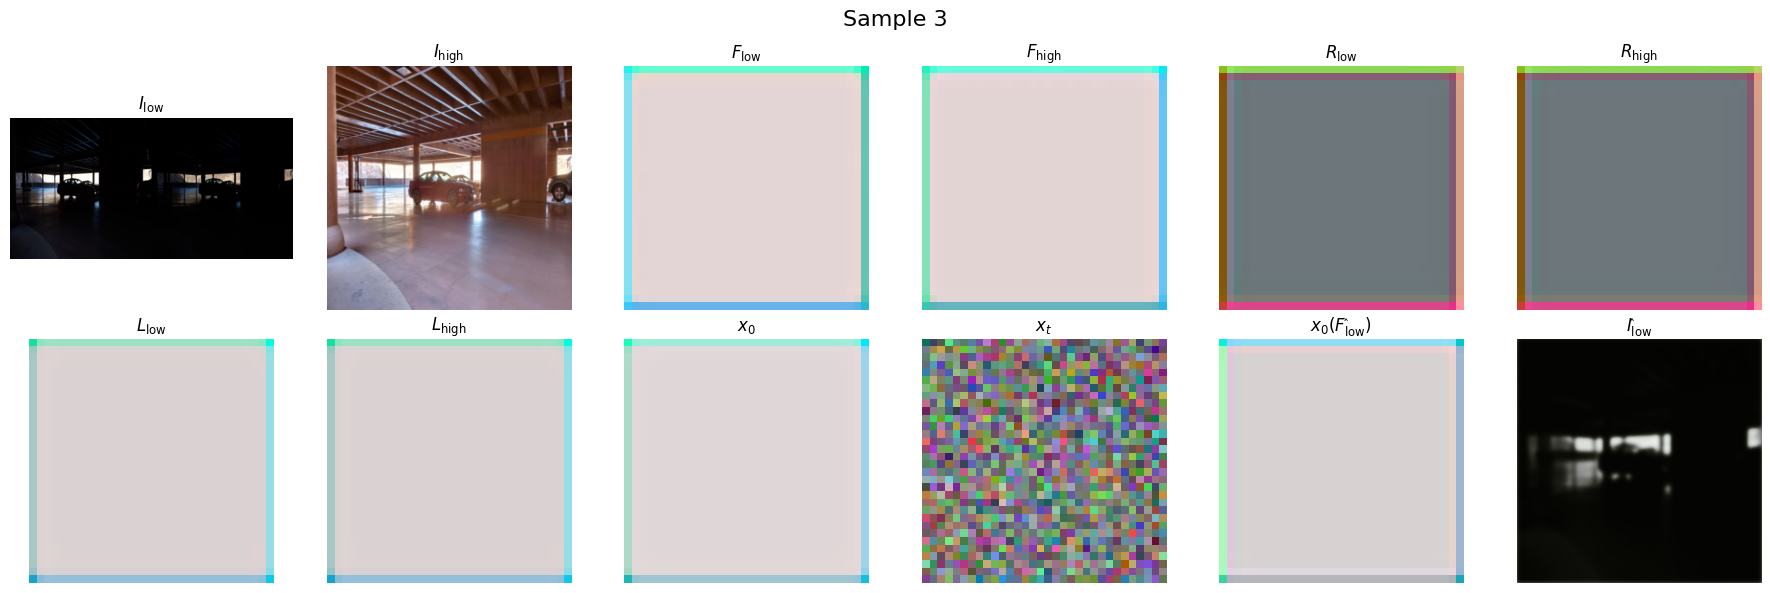

Training Batches:   0%|          | 0/26 [00:00<?, ?batch/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

...




Evaluating Stage2 (Average-First): 100%|██████████| 7/7 [00:35<00:00,  5.07s/it]


{'psnr': np.float64(10.419697223489052),
 'ssim': np.float64(0.3280003198242739),
 'lpips': 0.8077777156642839,
 'niqe': 12.84436405230379,
 'pi': 6.826070883984038}

Visualizing Stage2 results


Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

Reverse Sampling:   0%|          | 0/50 [00:00<?, ?step/s]

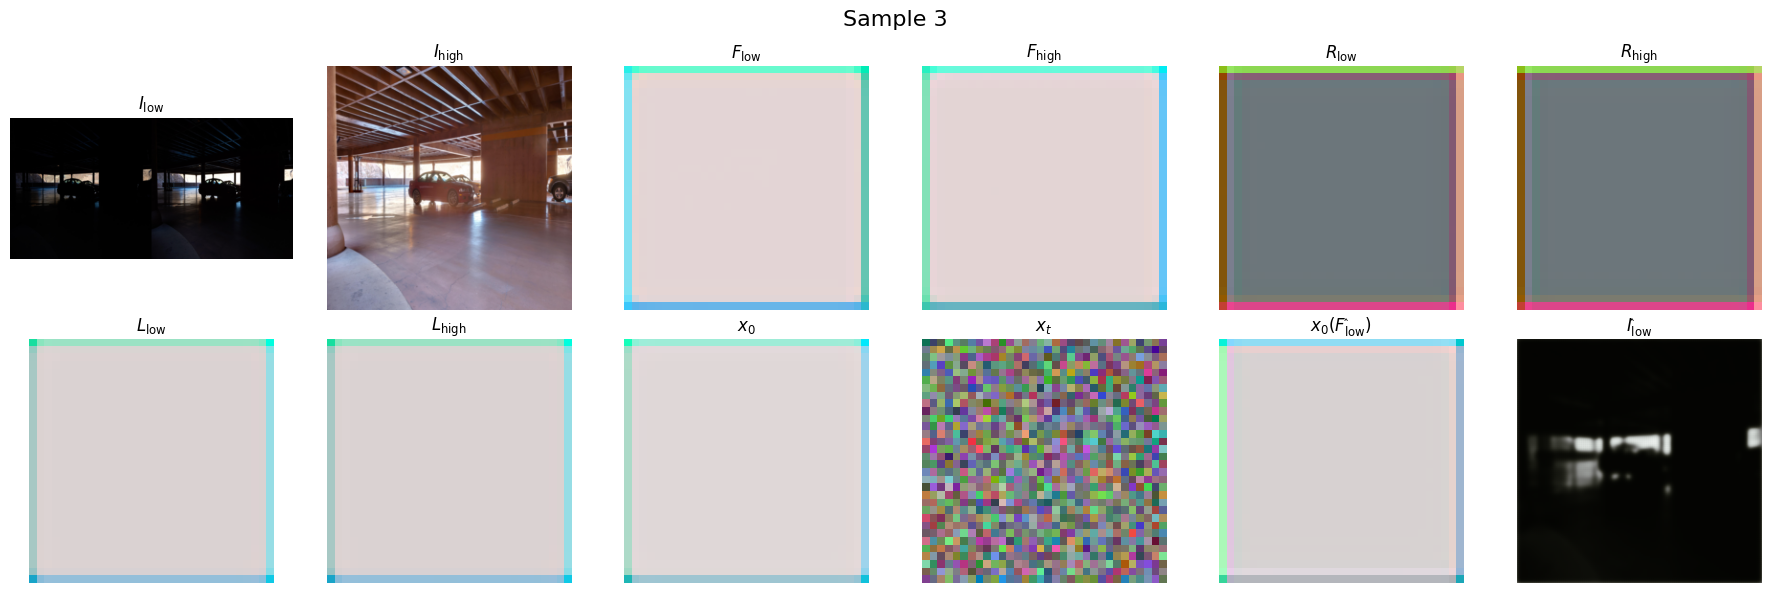

In [ ]:
num_diffusion_steps = 1000
num_epochs = 50
val_frequency = 5
patience = val_frequency * 2

trainer2 = Stage2Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=stage2_optimizer,
    device=device,
    num_epochs=num_epochs,
    val_frequency =  val_frequency,
    scheduler=stage2_scheduler, 
    patience = patience,
    lambda_scc=0.01,
    betas=torch.linspace(0.0001, 0.02, steps=num_diffusion_steps),
    num_diffusion_timesteps=num_diffusion_steps,
    num_sampling_timesteps=50,
    gamma=0.2
)
best_stage2, metrics2 = trainer2.train()


In [ ]:
directory = "/home/grads/o/omarkhater/projects/lle-generative-priors/frameworks/LightenDiffusion/trained_models"
file_path = os.path.join(directory, "stage2/lighten_diffusion_beta2.pth")
if not os.path.exists(directory):
    os.makedirs(directory)
torch.save(best_stage2.state_dict(), file_path)